In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import os

dataset_dir = '/kaggle/input/datasets/alessiocorrado99/animals10/raw-img'

In [4]:
batch_size = 32
img_height = 227
img_width = 227

train_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(f"Класи: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.


I0000 00:00:1776270097.171924      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776270097.177839      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 26179 files belonging to 10 classes.
Using 5235 files for validation.
Класи: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


In [5]:
num_classes = 10

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(96, (11, 11), strides=(4, 4), activation='relu'),
    layers.MaxPooling2D((3, 3), strides=(2, 2)),
    layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
    layers.MaxPooling2D((3, 3), strides=(2, 2)),
    layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((3, 3), strides=(2, 2)),
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, validation_data=val_ds, epochs=30)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30


I0000 00:00:1776270284.529101     136 service.cc:152] XLA service 0x799798009170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776270284.529162     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776270284.529166     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776270285.146946     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/655 ━━━━━━━━━━━━━━━━━━━━ 45s 70ms/step - accuracy: 0.0234 - loss: 2.3213        

I0000 00:00:1776270293.079069     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


655/655 ━━━━━━━━━━━━━━━━━━━━ 114s 75ms/step - accuracy: 0.2215 - loss: 2.1414 - val_accuracy: 0.4342 - val_loss: 1.6029
Epoch 2/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.4605 - loss: 1.5515 - val_accuracy: 0.5727 - val_loss: 1.2522
Epoch 3/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.5937 - loss: 1.1887 - val_accuracy: 0.6436 - val_loss: 1.0430
Epoch 4/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step - accuracy: 0.6736 - loss: 0.9655 - val_accuracy: 0.6445 - val_loss: 1.0667
Epoch 5/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.7270 - loss: 0.8072 - val_accuracy: 0.7072 - val_loss: 0.8788
Epoch 6/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.7767 - loss: 0.6604 - val_accuracy: 0.7104 - val_loss: 0.8838
Epoch 7/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.8260 - loss: 0.5173 - val_accuracy: 0.7387 - val_loss: 0.8159
Epoch 8/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.8692 - loss: 0.3805 - val_accura

In [6]:
#load model to file
model.save('my_alexnet_model.keras')

In [ ]:
model = tf.keras.models.load_model('my_alexnet_model.keras')

Accuracy:  0.7480
Precision: 0.7570
Recall:    0.7480
F1-Score:  0.7498


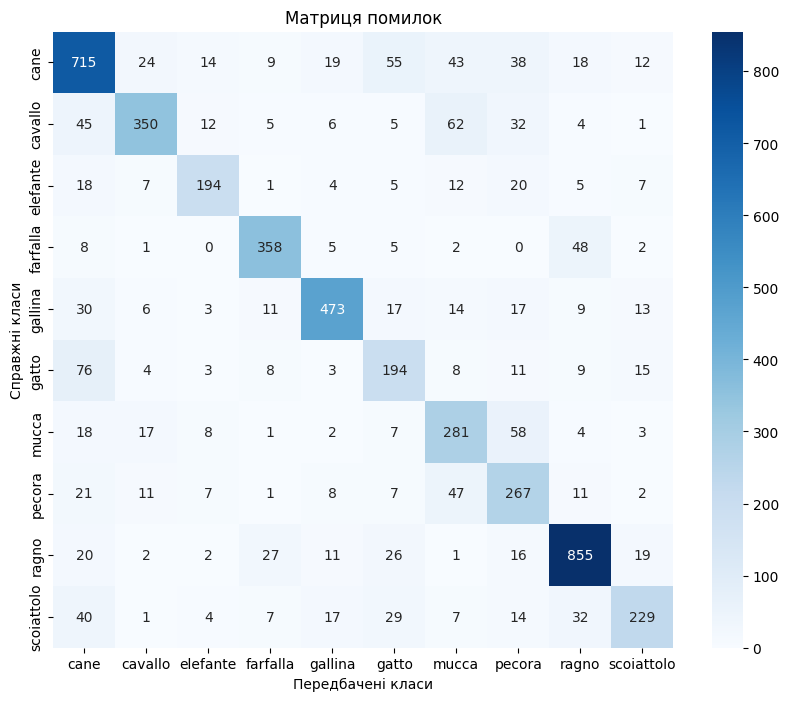

In [ ]:
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred, average='weighted'):.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Передбачені класи')
plt.ylabel('Справжні класи')
plt.title('Матриця помилок')
plt.show()

In [ ]:
def predict_image_from_url(img_url, trained_model, class_names):
    try:
        img_path = tf.keras.utils.get_file('test_img.jpg', origin=img_url)
        
        img = tf.keras.utils.load_img(img_path, target_size=(227, 227))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0) 
        
        predictions = trained_model.predict(img_array, verbose=0)
        score = tf.nn.softmax(predictions[0])
        predicted_class = class_names[np.argmax(predictions[0])]
        confidence = 100 * np.max(score)
        
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Прогноз: {predicted_class} ({confidence:.2f}%)")
        plt.show()
        
        os.remove(img_path)
        
    except Exception as e:
        print(f"Помилка: {e}")

116212/116212 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


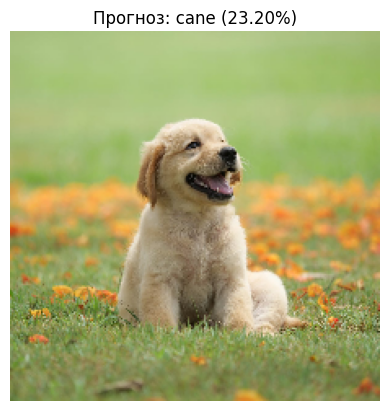

23782/23782 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


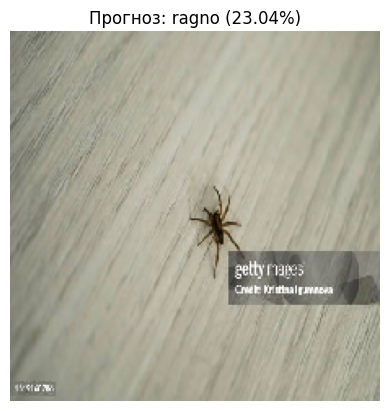

46165/46165 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


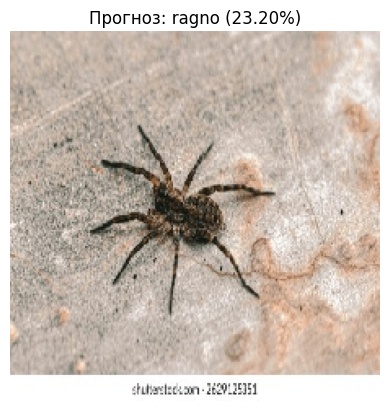

29285/29285 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


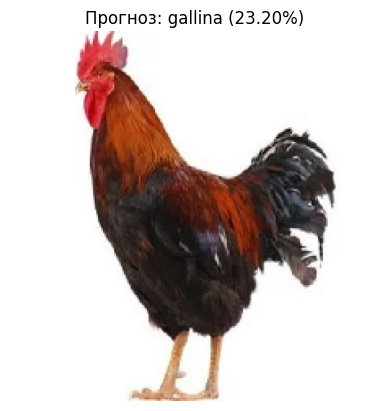

In [26]:
random_dog_url = "https://hips.hearstapps.com/hmg-prod/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg?crop=0.752xw:1.00xh;0.175xw,0&resize=1200:*"
random_spider_url = "https://media.gettyimages.com/id/1619168786/photo/small-spider-crawls-on-the-floor-on-tiles-copy-space-pests-and-insects.jpg?s=612x612&w=gi&k=20&c=07PfVprREHgALrobXi0uaE7gZTtSj0dOyY2vQPEkDoo="
random_spider_2 = "https://www.shutterstock.com/image-photo/closeup-captures-wolf-spider-perched-260nw-2629125351.jpg"
rooster = "https://tiimg.tistatic.com/fp/1/007/791/reddish-black-brown-rooster-breed-chicken-weight-2-kg-459.jpg"

predict_image_from_url(random_dog_url, model, class_names)
predict_image_from_url(random_spider_url, model, class_names)
predict_image_from_url(random_spider_2, model, class_names)
predict_image_from_url(rooster, model, class_names)